##Iris Flower Classification

Oasis Infobyte Data Science Internship
Task 1 — Iris Flower Classification

Objective:
Build a machine learning classification model to predict
the species of an Iris flower using its physical measurements.

##Steps Included

1. Import Required Libraries

2. Load the Iris Dataset

3. Convert the Dataset into a Pandas DataFrame

4. Understand the Dataset

5. Exploratory Data Analysis (EDA)

6. Analyze Class Distribution

7. Data Visualization

8. Feature Analysis

9. Prepare Features and Target (X and y)

10. Split the Dataset into Training and Testing Sets

11. Train Logistic Regression Model

12. Train K-Nearest Neighbors (KNN) Model

13. Train Random Forest Classifier Model

14. Make Predictions

15. Evaluate Model Performance

16. Compare the Classification Models

17. Select the Best-Performing Model

18. Conclusion

##Step 1: Import Required Libraries

In [2]:
#Data manipulation
import pandas as pd
import numpy as np

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#DataSet
from sklearn.datasets import load_iris

# Train-Test Split
from sklearn.model_selection import train_test_split

#Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Machine Learning Models
from sklearn.preprocessing import StandardScaler,MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

##Step 2: Load the Iris Dataset

In [3]:
iris = load_iris()

##Step 3: Convert the Dataset into a Pandas DataFrame

In [4]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df["species"] = iris.target

##Step 4: Understand the Dataset

In [5]:
df.shape

(150, 5)

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [9]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
142,5.8,2.7,5.1,1.9,2


In [12]:
df[df.duplicated(keep=False)]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
101,5.8,2.7,5.1,1.9,2
142,5.8,2.7,5.1,1.9,2


In [13]:
#Dropping the Duplicate

df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

##Duplicate Check:
One exact duplicate observation was identified in the dataset. To avoid repeated identical observations potentially influencing the analysis and model training, the duplicate was removed. The dataset now contains 149 unique observations.

##Step 5: Exploratory Data Analysis (EDA)

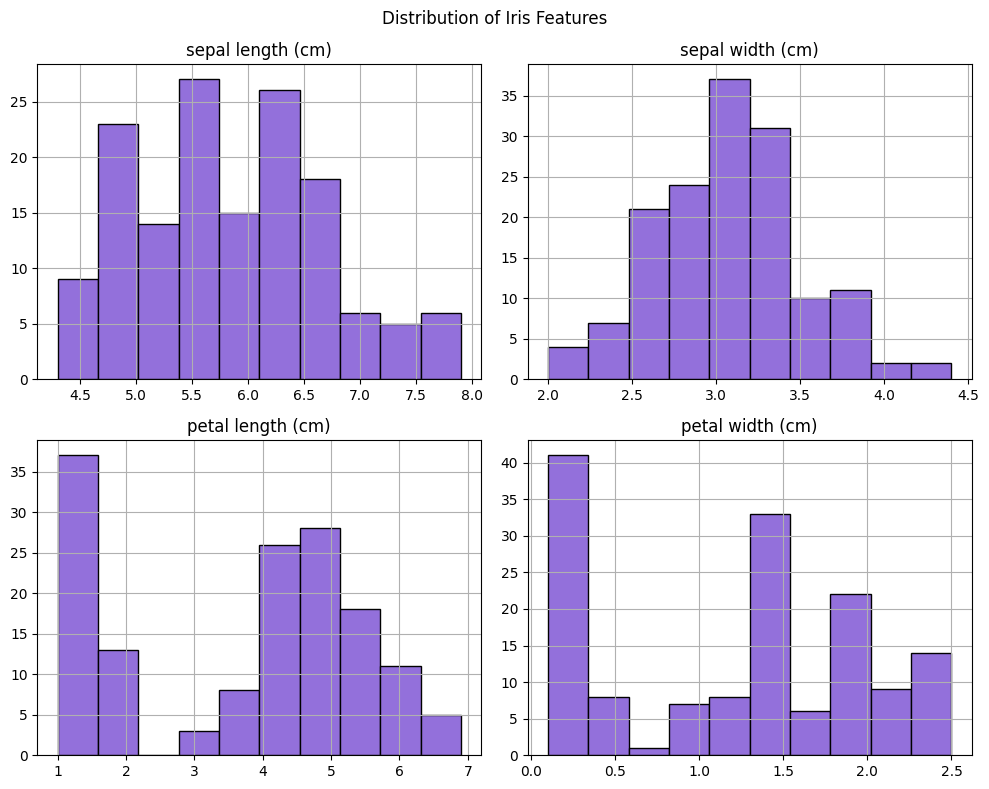

In [15]:
#Distribution of each numerical feature

df.drop(columns="species").hist(
    figsize=(10, 8),
    color="mediumpurple",
    edgecolor="black"
)

plt.suptitle("Distribution of Iris Features")
plt.tight_layout()
plt.show()

###Observation:Petal length and petal width show more distinct groupings than sepal measurements, suggesting that petal features may be more useful for distinguishing Iris species.

##Step  6:Analyze Class Distribution

In [16]:
df["species"].value_counts()

,count
species,
0,50
1,50
2,49


###Observation:All three species contain approximately the same number of observations, indicating no significant class imbalance in the dataset.

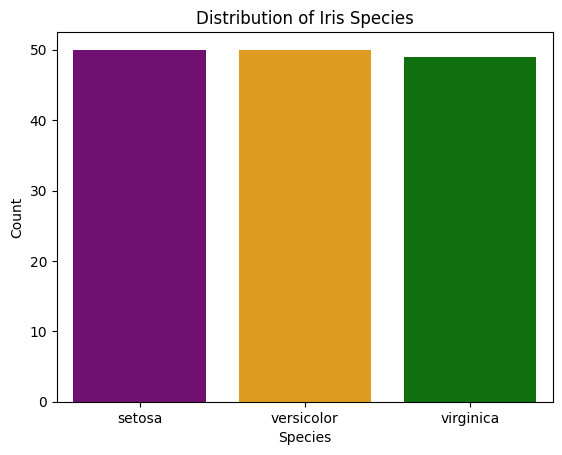

In [17]:
#Class Distribution Count Plot

species_palette = {
    0: "purple",
    1: "orange",
    2: "green"
}

sns.countplot(
    data=df,
    x="species",
    hue="species",
    palette=species_palette,
    legend=False
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks([0, 1, 2], iris.target_names)
plt.show()

###Observation:The dataset is nearly balanced across the three Iris species, with 50 Setosa, 50 Versicolor, and 49 Virginica samples after duplicate removal.

##Step 7 : Data Visualization

In [18]:
df["species_name"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

In [19]:
species_colors = {
    "setosa": "purple",
    "versicolor": "orange",
    "virginica": "green"
}

###Feature Relationships by Species(Pairplot)

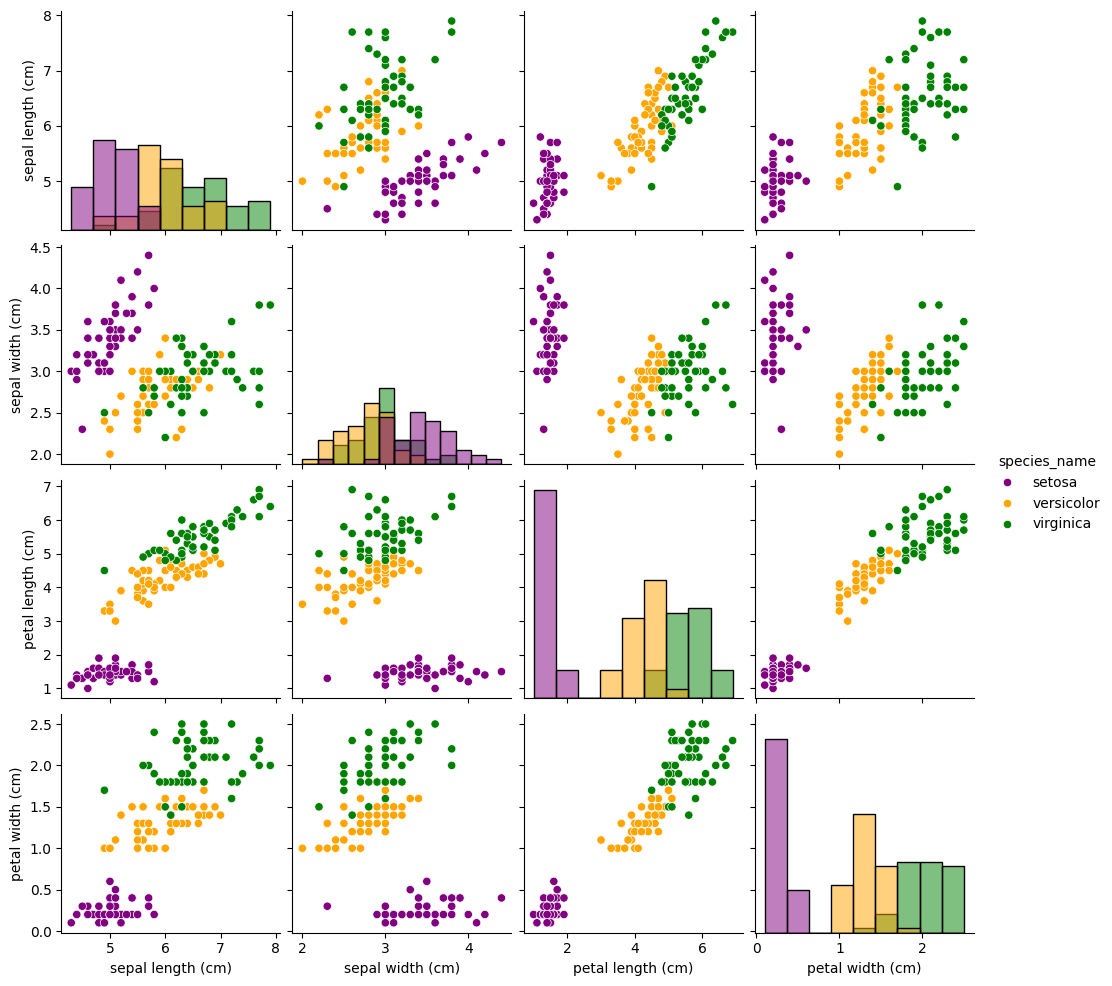

In [20]:
sns.pairplot(
    df,
    vars=iris.feature_names,
    hue="species_name",
    palette=species_colors,
    diag_kind="hist"
)

plt.show()

###Observation: The pairplot shows that Setosa is clearly separated from the other species, especially using petal measurements, while Versicolor and Virginica show some overlap. Petal length and petal width provide the clearest separation among the three species.

###Feature Distribution by Species(Box Plots)

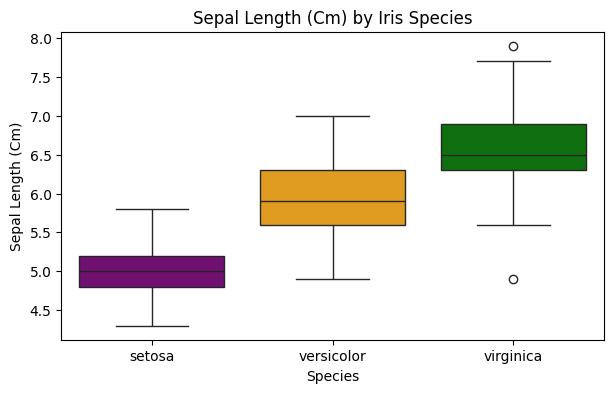

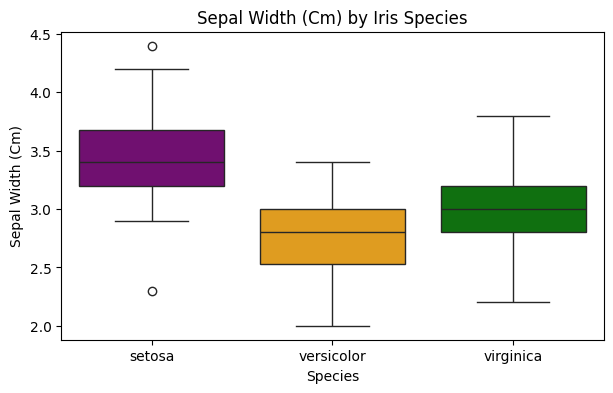

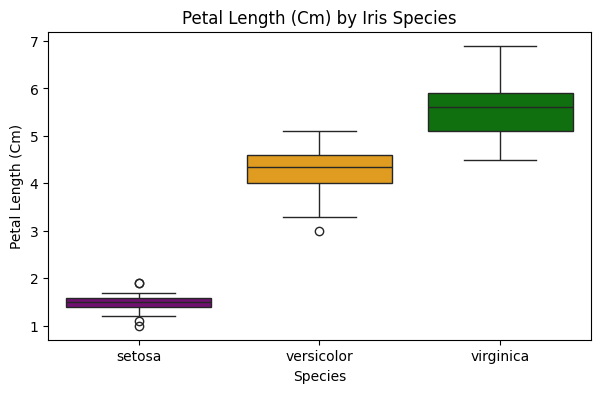

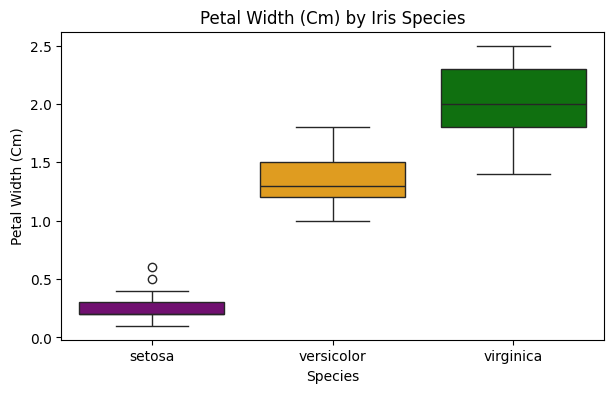

In [21]:
for feature in iris.feature_names:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="species_name",
        y=feature,
        hue="species_name",
        palette=species_colors,
        legend=False
    )

    plt.title(f"{feature.title()} by Iris Species")
    plt.xlabel("Species")
    plt.ylabel(feature.title())
    plt.show()

###Observation: (For Sepal Length) Sepal length generally increases from Setosa to Versicolor to Virginica, although there is considerable overlap between the species.
###(For Sepal Width) Observation: Setosa generally has a higher sepal width, while Versicolor and Virginica show considerable overlap, making sepal width less effective for species separation.
###(For Petal Length) Observation: Petal length provides strong separation among the species, with Setosa having the shortest petals, Versicolor intermediate petals, and Virginica the longest petals.
###(For Petal Width) Observation: Petal width clearly distinguishes Setosa from the other species and provides good separation between Versicolor and Virginica, making it a strong classification feature.

###Correlation Heatmap

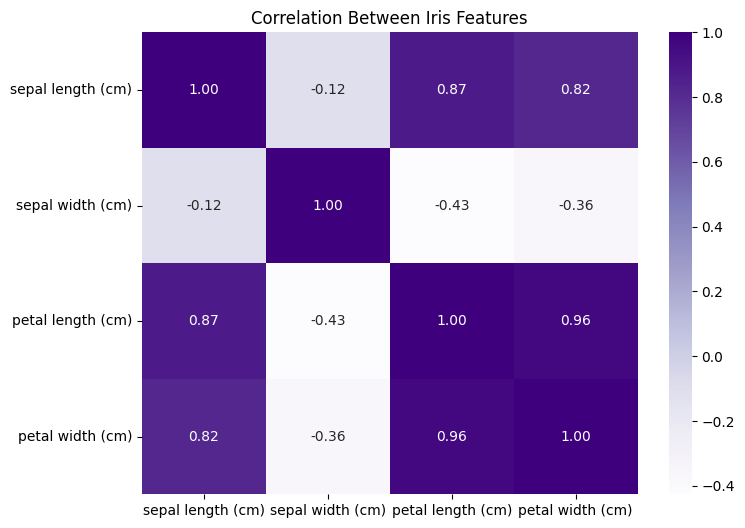

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[iris.feature_names].corr(),
    annot=True,
    cmap="Purples",
    fmt=".2f"
)

plt.title("Correlation Between Iris Features")
plt.show()

###Observation: Petal length and petal width have a very strong positive correlation (0.96), while sepal length is also strongly correlated with both petal length (0.87) and petal width (0.82). Sepal width shows weaker and mostly negative correlations with the other features.

## Step 8: Feature Analysis

In [23]:
#Mean feature values by species

feature_means = df.groupby("species_name")[iris.feature_names].mean()
feature_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species_name,,,,
setosa,5.006000,3.428000,1.462000,0.246000
versicolor,5.936000,2.770000,4.260000,1.326000
virginica,6.604082,2.979592,5.561224,2.028571


###Observation: Petal length and petal width show the clearest differences among the three Iris species. Setosa has the smallest mean petal measurements, Versicolor has intermediate values, and Virginica has the largest values. Therefore, petal length and petal width appear to be the most discriminative features for Iris species classification.

##Step 9 : Prepare Features and Target (X and y)

In [24]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species', 'species_name'],
      dtype='object')

In [25]:
X=df.drop(['species','species_name'],axis=1)
y=df['species']

In [26]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [27]:
y.head()

,species
0,0
1,0
2,0
3,0
4,0


##Step 10: Split the Dataset into Training and Testing Sets

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,


    random_state=42
)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((119, 4), (30, 4), (119,), (30,))

##Step 11: Train Logistic Regression Model

In [29]:
logistic_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("classifier", LogisticRegression(max_iter=200))
])

logistic_model.fit(X_train, Y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('classifier', LogisticRegression(max_iter=200))])

##Step 12: Train K-Nearest Neighbors (KNN) Model

In [30]:
knn_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, Y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('classifier', KNeighborsClassifier())])

##Step 13: Train Random Forest Classifier Model

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

##Step 14: Make Predictions

In [32]:
y_pred_logistic = logistic_model.predict(X_test)

y_pred_knn = knn_model.predict(X_test)

y_pred_rf = rf_model.predict(X_test)

print("Logistic Regression:", y_pred_logistic)
print("KNN:", y_pred_knn)
print("Random Forest:", y_pred_rf)

Logistic Regression: [1 1 2 0 2 1 1 0 2 2 0 0 0 1 2 0 2 0 2 0 1 1 0 0 1 1 2 2 2 2]
KNN: [1 1 2 0 2 1 1 0 2 2 0 0 0 1 2 0 1 0 2 0 1 1 0 0 1 1 2 2 2 1]
Random Forest: [1 1 2 0 2 1 1 0 2 2 0 0 0 1 2 0 2 0 2 0 1 1 0 0 1 1 2 2 2 1]


In [33]:
print(len(y_pred_logistic))
print(len(y_pred_knn))
print(len(y_pred_rf))

30
30
30


##Step 15: Evaluate Model Performance

In [34]:
#Accuracy

logistic_accuracy = accuracy_score(Y_test, y_pred_logistic)
knn_accuracy = accuracy_score(Y_test, y_pred_knn)
rf_accuracy = accuracy_score(Y_test, y_pred_rf)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("KNN Accuracy:", knn_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.9
KNN Accuracy: 0.9666666666666667
Random Forest Accuracy: 0.9333333333333333


In [35]:
#Classification Report

print("Logistic Regression Classification Report")
print(classification_report(Y_test, y_pred_logistic, target_names=iris.target_names))

print("KNN Classification Report")
print(classification_report(Y_test, y_pred_knn, target_names=iris.target_names))

print("Random Forest Classification Report")
print(classification_report(Y_test, y_pred_rf, target_names=iris.target_names))

Logistic Regression Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

KNN Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Random Forest Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90  

In [36]:
#Confusion Matrix

cm_logistic = confusion_matrix(Y_test, y_pred_logistic)
cm_knn = confusion_matrix(Y_test, y_pred_knn)
cm_rf = confusion_matrix(Y_test, y_pred_rf)

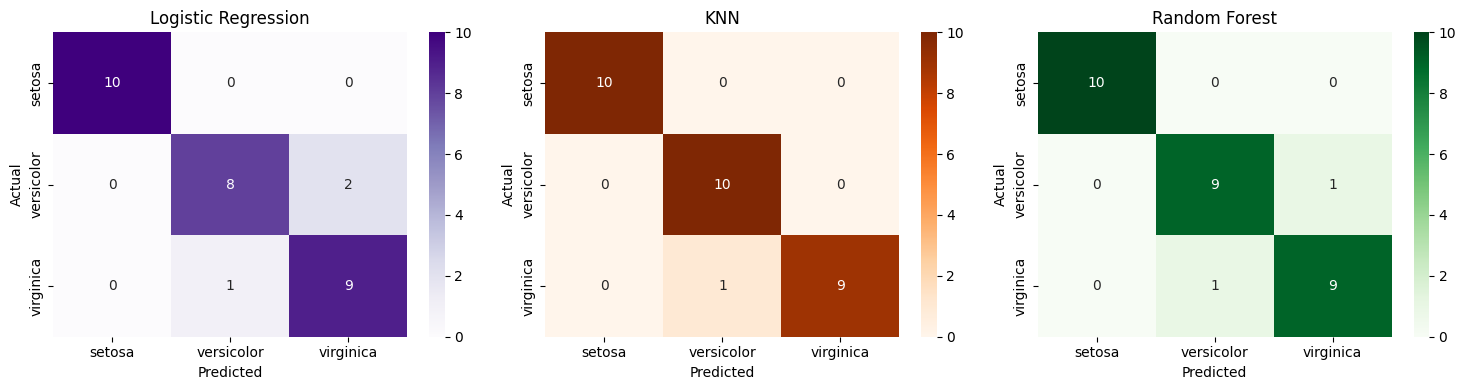

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=axes[1]
)
axes[1].set_title("KNN")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=axes[2]
)
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [38]:
for name, y_pred in [
    ("Logistic Regression", y_pred_logistic),
    ("KNN", y_pred_knn),
    ("Random Forest", y_pred_rf)
]:
    print(f"\n{name}")
    print("Precision:", precision_score(Y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(Y_test, y_pred, average="weighted"))
    print("F1-score:", f1_score(Y_test, y_pred, average="weighted"))


Logistic Regression
Precision: 0.9023569023569025
Recall: 0.9
F1-score: 0.8997493734335839

KNN
Precision: 0.9696969696969696
Recall: 0.9666666666666667
F1-score: 0.9665831244778613

Random Forest
Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1-score: 0.9333333333333333


##Step 16: Compare the Classification Models

In [39]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest"],
    "Accuracy": [
        accuracy_score(Y_test, y_pred_logistic),
        accuracy_score(Y_test, y_pred_knn),
        accuracy_score(Y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(Y_test, y_pred_logistic, average="weighted"),
        precision_score(Y_test, y_pred_knn, average="weighted"),
        precision_score(Y_test, y_pred_rf, average="weighted")
    ],
    "Recall": [
        recall_score(Y_test, y_pred_logistic, average="weighted"),
        recall_score(Y_test, y_pred_knn, average="weighted"),
        recall_score(Y_test, y_pred_rf, average="weighted")
    ],
    "F1-Score": [
        f1_score(Y_test, y_pred_logistic, average="weighted"),
        f1_score(Y_test, y_pred_knn, average="weighted"),
        f1_score(Y_test, y_pred_rf, average="weighted")
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.900,0.902,0.900,0.900
1,KNN,0.967,0.970,0.967,0.967
2,Random Forest,0.933,0.933,0.933,0.933


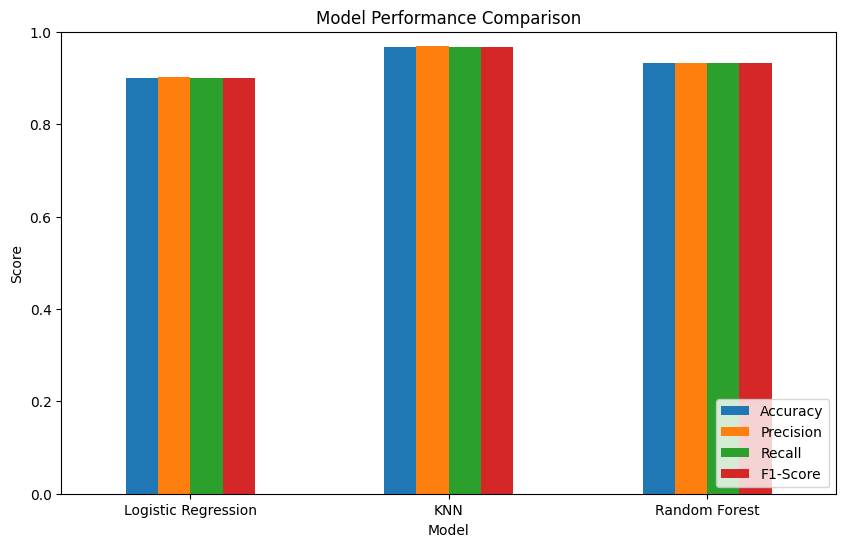

In [40]:
model_comparison.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1-Score"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

##Observation: KNN achieved the highest overall performance with an accuracy of 96.67% and an F1-score of approximately 0.97. Random Forest performed second with 93.33% accuracy, while Logistic Regression achieved 90% accuracy. KNN also produced the fewest misclassifications, making it the strongest model among the three on the test set.

##Step 17: Select the Best-Performing Model

In [41]:
best_model_name = model_comparison.loc[
    model_comparison["F1-Score"].idxmax(), "Model"
]

print("Best Performing Model:", best_model_name)

Best Performing Model: KNN


##Step 18: Conclusion

In this project, the Iris dataset was loaded using sklearn.datasets.load_iris() and analyzed through exploratory data analysis and visualization. The dataset was cleaned by removing one exact duplicate observation and was found to contain no missing values.

The EDA showed that petal length and petal width are the most discriminative features, providing clearer separation between the three Iris species than the sepal measurements.

Three classification models were trained and evaluated: Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest. The models were compared using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.

Among the three models, KNN achieved the best performance, with an accuracy of 96.67%, precision of 97.00%, recall of 96.67%, and F1-score of 96.67% on the test set. Therefore, KNN was selected as the best-performing model for this particular dataset and test split.

This project demonstrated the complete machine learning workflow, from data loading and EDA to visualization, feature analysis, model training, evaluation, and model selection.